# Objective

The goal of this project is to develop an NLP model capable of predicting Market sentiment based on
tweets. In summary, with the NLP techniques you have learned during class, you must implement a
classifier that receives tweets as inputs and is able to predict, for each tweet, if it describes a Bearish
(0), Bullish (1), or Neutral (2) attitude.
The project should be developed using python 3 and libraries such as NLTK and Scikit Learn. Also, the
project is simple and can be solved in various ways, which means there is no exact correct solution.
Students should not use code from each other!

# Corpora

The data is divided in a file for training “train.csv”, and another file for testing “test.csv”:
• Train (9543 lines): Presents the tweets (“text”) and the sentiment label (“label”). Each tweet can have
one of the following labels: Bearish (0), Bullish (1), or Neutral (2). You can divide this set in
Train/Validation.

In [233]:
# Data Handling and Manipulation
import pandas as pd
import numpy as np

# Visualization Libraries
from matplotlib import pyplot as plt
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, TFAutoModel, EarlyStoppingCallback
from sentence_transformers import SentenceTransformer

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB

# Transformers
import tensorflow as tf
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

#Other
import scipy
import re
from tqdm import tqdm
import string
import contractions
from datasets import Dataset

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [5]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
df = pd.read_csv("train.csv")
print(df.head(3))
print(df.tail(3))

                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
                                                   text  label
9540  vTv Therapeutics leads healthcare gainers; Myo...      2
9541    WORK, XPO, PYX and AMKR among after hour movers      2
9542             YNDX, I, QD and OESX among tech movers      2


# 1. Data Exploration (1.75pts)
Here you should analyze the corpora and provide some conclusions
and visual information (bar charts, word clouds, etc.) that contextualize the data.

In [ ]:
#check for any missing values
print(df['label'].isna().sum() )
print(df['text'].isna().sum() )

0
0


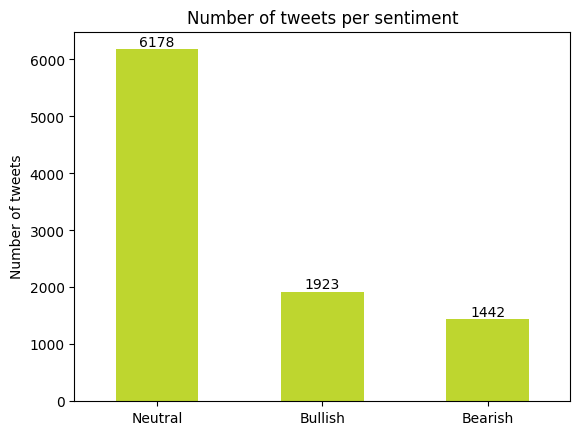

In [ ]:
#attribute the meaning to the labels 2-neutral, 1-bullish and 0 bearish for visualization purposes
df["sentiment"] = df["label"].map({2:"Neutral", 1:"Bullish", 0:"Bearish"})

# histogram with labels
df["sentiment"].value_counts().plot(kind="bar",color="#BED62F")
plt.title("Number of tweets per sentiment")
plt.xlabel("")
plt.ylabel("Number of tweets")
plt.bar_label(plt.gca().containers[0])
plt.xticks(rotation=0, ha='center')
plt.show()

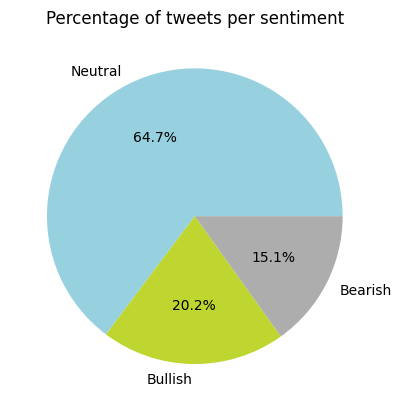

In [ ]:
#pie chart with percentagens for the bullish and bearish
df["sentiment"].value_counts(normalize=True).plot(kind="pie", autopct='%1.1f%%', colors=['#97D1DF','#BED62F', '#ADADAD'])
plt.title("Percentage of tweets per sentiment")
plt.ylabel("")
plt.show()

In [ ]:
#word count
all_words = ' '.join(df['text']).split()
freq=pd.Series(all_words).value_counts()
freq.head(10)

,count
to,2332
the,1820
of,1464
-,1390
in,1361
on,1136
for,1032
a,970
and,898
The,663


(-0.5, 1999.5, 999.5, -0.5)

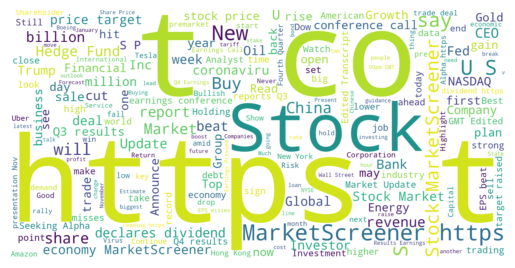

In [15]:
#create a word cloud for the whole file

words= ' '.join(df.text)
wordcloud = WordCloud(width = 2000, height = 1000,
                background_color ='white',
                min_font_size = 10).generate(words)
plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

# 2. Corpus split (0.25pts)
You must apply some method to split your training corpus into
train/validation sets to evaluate the performance of your model. You can also resort to K-Fold cross
validation

In [27]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.25, random_state=42)

In [19]:
len(X_train), len(X_test), len(y_train), len(y_test)

(7157, 2386, 7157, 2386)

In [21]:
X_train.head(3)

6735    The Dow just gave up nearly all of its 940-poi...
1281    Aurora Cannabis : Jordan Cove Energy Project P...
5814                      Fiat settles tax issue in Italy
Name: text, dtype: object

In [23]:
y_train.head(3)

6735    0
1281    2
5814    1
Name: label, dtype: int64

In [25]:

print(X_train[6735])

The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp


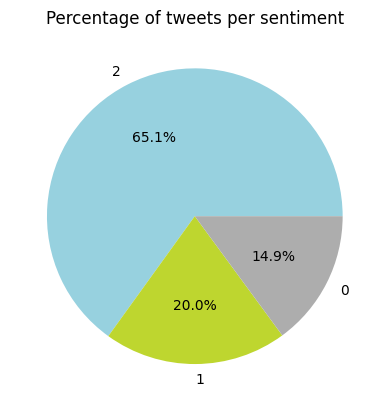

In [ ]:
#check if training corpus distribution
y_train.value_counts(normalize=True).plot(kind="pie", autopct='%1.1f%%', colors=['#97D1DF','#BED62F', '#ADADAD'])
plt.title("Percentage of tweets per sentiment")
plt.ylabel("")
plt.show()

Similar distribution as the original dataset

# 3. Data Preprocessing (3pts)
You must correctly implement and experiment at least four (4) of the
data preprocessing techniques shown in class (stop words, regular expressions, lemmatization,
stemming, etc.).

In [11]:
# Exclude punctuation
exclude = set(string.punctuation)

# Stopwords (common words like "the", "is")
stop = set(stopwords.words('english'))

In [ ]:
#testing - to be deleted
text="I shouldn't have bought this stock, at this price"
print(text.split())
print(word_tokenize(text))
print([word for word in text.split() if word not in exclude])
print([word for word in word_tokenize(text) if word not in exclude]) #actually removes punctuation
print([word for word in text.split() if word not in stop])
print([word for word in word_tokenize(text) if word not in stop]) #keeps the negative sentiment in the sentence.

['I', "shouldn't", 'have', 'bought', 'this', 'stock,', 'at', 'this', 'price']
['I', 'should', "n't", 'have', 'bought', 'this', 'stock', ',', 'at', 'this', 'price']
['I', "shouldn't", 'have', 'bought', 'this', 'stock,', 'at', 'this', 'price']
['I', 'should', "n't", 'have', 'bought', 'this', 'stock', 'at', 'this', 'price']
['I', 'bought', 'stock,', 'price']
['I', "n't", 'bought', 'stock', ',', 'price']


In [ ]:
def update_df(dataframe, list_updated):
    dataframe.update(pd.DataFrame({"text": list_updated}))

## Punctuation

In [13]:
exclude = set(string.punctuation)
exclude

{'!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~'}

In [ ]:
def clean_punctuation(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #remove punctuation
        text = " ".join(word for word in word_tokenize(text) if word not in exclude)
        updates.append(text)

    return updates

In [ ]:
updates_punctuation=clean_punctuation(df.text)

100%|██████████| 9543/9543 [00:01<00:00, 5809.54it/s]


In [ ]:
#testing
print(df.text[0])
print(updates_punctuation[0])
print(df.text[221])
print(updates_punctuation[221])
print(df.text[229])
print(updates_punctuation[229])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
BYND JPMorgan reels in expectations on Beyond Meat https //t.co/bd0xbFGjkT
CSX stock price target raised to $90 from $72 at Deutsche Bank
CSX stock price target raised to 90 from 72 at Deutsche Bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Earnings Update Here 's Why Analysts Just Lifted Their Aemetis Inc. Price Target To US 2.25


## Lowercasing

In [ ]:
def clean_lower(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #lowercasing
        text = text.lower()
        updates.append(text)

    return updates

In [ ]:
#testing
updates_lower=clean_lower(df['text'])

100%|██████████| 9543/9543 [00:00<00:00, 823636.09it/s]


In [ ]:
print(df.text[0])
print(updates_lower[0])
print(df.text[221])
print(updates_lower[221])
print(df.text[229])
print(updates_lower[229])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
$bynd - jpmorgan reels in expectations on beyond meat https://t.co/bd0xbfgjkt
CSX stock price target raised to $90 from $72 at Deutsche Bank
csx stock price target raised to $90 from $72 at deutsche bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
earnings update: here's why analysts just lifted their aemetis, inc. price target to us$2.25


## Stop Words

In [15]:
stop = set(stopwords.words('english'))
stop


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'r

In [ ]:
def clean_stopwords(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #remove stopwords
        text = " ".join([word for word in word_tokenize(text) if word not in stop])
        updates.append(text)

    return updates

In [ ]:
#testing
updates_stopwords=clean_stopwords(df['text'])


100%|██████████| 9543/9543 [00:01<00:00, 6112.21it/s]


In [ ]:
print(df.text[0])
print(updates_stopwords[0])
print(df.text[221])
print(updates_stopwords[221])
print(df.text[229])
print(updates_stopwords[229])
print(df.text[6735])
print(updates_stopwords[6735])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
$ BYND - JPMorgan reels expectations Beyond Meat https : //t.co/bd0xbFGjkT
CSX stock price target raised to $90 from $72 at Deutsche Bank
CSX stock price target raised $ 90 $ 72 Deutsche Bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Earnings Update : Here 's Why Analysts Just Lifted Their Aemetis , Inc. Price Target To US $ 2.25
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
The Dow gave nearly 940-point gain stock-market rally stumbles headed close https : //t.co/NHS6o1CYRp


## Regular Expressions





Seen in the data:


*   $10 - prices

*   $AMD - stocks

* https://t.co/  - external links

* US$2.25,1 - prices

* C$50,1 - prices

In [ ]:
def clean_re(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #remove links
        text = re.sub(r'http\S+', '', text)
        #substitute prices
        text = re.sub(r'([A-Z]+)?\$[\d,.]+', 'price', text)
        #substitute stocks
        text = re.sub(r'\$\w+', 'stock', text)

        updates.append(text)

    return updates

In [ ]:
updates_re=clean_re(df['text'])


100%|██████████| 9543/9543 [00:00<00:00, 95713.97it/s]


In [ ]:
print(df.text[0])
print(updates_re[0])
print(df.text[221])
print(updates_re[221])
print(df.text[229])
print(updates_re[229])
print(df.text[6735])
print(updates_stopwords[6735])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
stock - JPMorgan reels in expectations on Beyond Meat 
CSX stock price target raised to $90 from $72 at Deutsche Bank
CSX stock price target raised to price from price at Deutsche Bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To price
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
The Dow gave nearly 940-point gain stock-market rally stumbles headed close https : //t.co/NHS6o1CYRp


## Stemming

In [17]:
stemmer = SnowballStemmer('english')

In [ ]:

for word in word_tokenize(df.text[1]):
    print(f"Stem of {word} is {stemmer.stem(word)}")
    print('--------------------New word----------------')

Stem of $ is $
--------------------New word----------------
Stem of CCL is ccl
--------------------New word----------------
Stem of $ is $
--------------------New word----------------
Stem of RCL is rcl
--------------------New word----------------
Stem of - is -
--------------------New word----------------
Stem of Nomura is nomura
--------------------New word----------------
Stem of points is point
--------------------New word----------------
Stem of to is to
--------------------New word----------------
Stem of bookings is book
--------------------New word----------------
Stem of weakness is weak
--------------------New word----------------
Stem of at is at
--------------------New word----------------
Stem of Carnival is carniv
--------------------New word----------------
Stem of and is and
--------------------New word----------------
Stem of Royal is royal
--------------------New word----------------
Stem of Caribbean is caribbean
--------------------New word----------------
Stem of h

In [ ]:
def clean_stem(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #stemming using split()
        text = " ".join(stemmer.stem(word) for word in text.split())

        updates.append(text)

    return updates

In [ ]:
updates_stem=clean_stem(df['text'])

100%|██████████| 9543/9543 [00:02<00:00, 4658.98it/s]


In [ ]:
print(df.text[0])
print(updates_stem[0])
print(df.text[221])
print(updates_stem[221])
print(df.text[229])
print(updates_stem[229])
print(df.text[6735])
print(updates_stopwords[6735])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
$bynd - jpmorgan reel in expect on beyond meat https://t.co/bd0xbfgjkt
CSX stock price target raised to $90 from $72 at Deutsche Bank
csx stock price target rais to $90 from $72 at deutsch bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
earn update: here whi analyst just lift their aemetis, inc. price target to us$2.25
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
The Dow gave nearly 940-point gain stock-market rally stumbles headed close https : //t.co/NHS6o1CYRp


## Lemmatization

In [19]:
lemma = WordNetLemmatizer()

In [ ]:
#testing
for word in word_tokenize(df.text[1]):
    print(f"Lemma of {word} is {lemma.lemmatize(word)}")
    print('--------------------New word----------------')

Lemma of $ is $
--------------------New word----------------
Lemma of CCL is CCL
--------------------New word----------------
Lemma of $ is $
--------------------New word----------------
Lemma of RCL is RCL
--------------------New word----------------
Lemma of - is -
--------------------New word----------------
Lemma of Nomura is Nomura
--------------------New word----------------
Lemma of points is point
--------------------New word----------------
Lemma of to is to
--------------------New word----------------
Lemma of bookings is booking
--------------------New word----------------
Lemma of weakness is weakness
--------------------New word----------------
Lemma of at is at
--------------------New word----------------
Lemma of Carnival is Carnival
--------------------New word----------------
Lemma of and is and
--------------------New word----------------
Lemma of Royal is Royal
--------------------New word----------------
Lemma of Caribbean is Caribbean
--------------------New word--

In [ ]:
def clean_lemma(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #stemming using split()
        text = " ".join(lemma.lemmatize(word) for word in text.split())

        updates.append(text)

    return updates

In [ ]:
updates_lemma=clean_lemma(df['text'])

100%|██████████| 9543/9543 [00:00<00:00, 17399.68it/s]


In [ ]:
#testing
print(f"Original: {df.text[0]}")
print(f"Stemming: {updates_stem[0]}")
print(f"Lemmatization: {updates_lemma[0]}")
print(f"Original: {df.text[221]}")
print(f"Stemming: {updates_stem[221]}")
print(f"Lemmatization: {updates_lemma[221]}")
print(f"Original: {df.text[229]}")
print(f"Stemming: {updates_stem[229]}")
print(f"Lemmatization: {updates_lemma[229]}")
print(f"Original: {df.text[6735]}")
print(f"Stemming: {updates_stem[6735]}")
print(f"Lemmatization: {updates_lemma[6735]}")

Original: $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
Stemming: $bynd - jpmorgan reel in expect on beyond meat https://t.co/bd0xbfgjkt
Lemmatization: $BYND - JPMorgan reel in expectation on Beyond Meat https://t.co/bd0xbFGjkT
Original: CSX stock price target raised to $90 from $72 at Deutsche Bank
Stemming: csx stock price target rais to $90 from $72 at deutsch bank
Lemmatization: CSX stock price target raised to $90 from $72 at Deutsche Bank
Original: Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Stemming: earn update: here whi analyst just lift their aemetis, inc. price target to us$2.25
Lemmatization: Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Original: The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
Stemming: the dow just gave up near all of it 940-point gain as stock-mar

## [Extra Points]
Data Preprocessing – 0.5 points for each extra method implemented and tested (maximum of 2 extra
methods).

## Expanding contractions

In [ ]:
#handle contractions

def clean_abbrev(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        text = contractions.fix(text)
        updates.append(text)

    return updates

In [ ]:
updates_abbrev=clean_abbrev(df['text'])

100%|██████████| 9543/9543 [00:00<00:00, 109666.35it/s]


In [ ]:
#testing
print(df.text[0])
print(updates_abbrev[0])
print(df.text[221])
print(updates_abbrev[221])
print(df.text[229])
print(updates_abbrev[229])
print(df.text[6735])
print(updates_abbrev[6735])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
CSX stock price target raised to $90 from $72 at Deutsche Bank
CSX stock price target raised to $90 from $72 at Deutsche Bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Earnings Update: Here is Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp


## Custom stop words

In [21]:
#stopwords keeping negative sentiment
stop_words = set(stopwords.words("english"))
negative_stopwords = {"not", "no", "never", "nor","up"}  # Define negative stopwords
custom_stop_words = stop_words - negative_stopwords  # Remove negatives from the stopword list

In [ ]:
def clean_stopwords_non_neg(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #remove stopwords
        text = " ".join([word for word in word_tokenize(text) if word not in custom_stop_words])
        updates.append(text)

    return updates

In [ ]:
updates_nn_sw=clean_stopwords_non_neg(df['text'])

100%|██████████| 9543/9543 [00:03<00:00, 2481.95it/s]


In [ ]:
#testing
print(df.text[0])
print(updates_abbrev[0])
print(df.text[221])
print(updates_abbrev[221])
print(df.text[229])
print(updates_abbrev[229])
print(df.text[6735])
print(updates_abbrev[6735])

$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
CSX stock price target raised to $90 from $72 at Deutsche Bank
CSX stock price target raised to $90 from $72 at Deutsche Bank
Earnings Update: Here's Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
Earnings Update: Here is Why Analysts Just Lifted Their Aemetis, Inc. Price Target To US$2.25
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp


## Update all

The order in which the preprocessing steps are applied is important.

In [23]:
def clean(text_list):
    updates = []
    for j in tqdm(text_list):
        text = j
        #1st - Regular expression because of the regex codes
          #remove links
        text = re.sub(r'http\S+', '', text)
          #substitute prices
        text = re.sub(r'([A-Z]+)?\$[\d,.]+', 'price', text)
          #substitute stocks
        text = re.sub(r'\$\w+', 'stock', text)

        #expand contractions
        text=contractions.fix(text)

        #2nd - Punctuation
        text = " ".join(word for word in word_tokenize(text) if word not in exclude)

        #3rd - Lowercasing
        text = text.lower()

        #4th - Stop words w/o removing negatives

        text = " ".join([word for word in word_tokenize(text) if word not in custom_stop_words])

        #5th - Choose between Stemming/Lemmatization (MR: I would choose Lemmatization given that the dataset and the sentences aren't too extensive)
        text = " ".join(lemma.lemmatize(word) for word in text.split())

        #Extras

        updates.append(text)

    return updates

In [29]:
X_train_clean = clean(X_train)

100%|██████████| 7157/7157 [00:02<00:00, 2635.95it/s]


In [30]:
X_test_clean= clean(X_test)

100%|██████████| 2386/2386 [00:00<00:00, 4558.36it/s]


In [69]:
print(X_train_clean[0])
print(X_train[6735])

dow gave up nearly 940-point gain stock-market rally stumble headed close
The Dow just gave up nearly all of its 940-point gain as stock-market rally stumbles headed into the close https://t.co/NHS6o1CYRp


# 4. Feature Engineering (4pts)
You must correctly implement and experiment three (3) of the feature
engineering techniques seen in class (BoW, TF-IDF, W2V).


## BoW

Create BoW

In [33]:
#Create BoW
bow = CountVectorizer(binary=True)
X_bow = bow.fit_transform(X_train_clean)


In [35]:
X_bow.shape

(7157, 11432)

In [37]:
X_test_bow=bow.transform(X_test_clean)
X_test_bow

<2386x11432 sparse matrix of type '<class 'numpy.int64'>'
	with 18277 stored elements in Compressed Sparse Row format>

In [ ]:
print(X_bow[1:60].toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print(bow.get_feature_names_out())

['00' '000' '0084' ... 'ímpeto' 'österreichische' 'übernahme']


## TF-IDF

In [39]:
#insert code for TF-IDF
tfidf = TfidfVectorizer(max_df=0.8, ngram_range=(1,2))

In [41]:
X_tfidf = tfidf.fit_transform(X_train_clean).toarray()

In [42]:
X_test_tfidf=tfidf.transform(X_test_clean).toarray()

In [45]:
X_tfidf.shape

(7157, 52453)

## W2V

In [ ]:

# Tokenize the sentences
tokenized_sentences = [word_tokenize(row.lower()) for row in X_train_clean]
#print(tokenized_sentences)


In [49]:
# Train Word2Vec model
model = Word2Vec(
    sentences=tokenized_sentences,  # Input tokenized sentences
    vector_size=100,                # Dimensionality of word vectors
    window=5,                       # Context window size
    min_count=2,                    # Minimum word frequency
    workers=4,                      # Number of worker threads
    sg=0                            # Skip-gram (1) or CBOW (0)
)

# Save the model for future use
model.save("word2vec.model")

In [51]:
model = Word2Vec.load("word2vec.model")

In [ ]:
# Get vector for a specific word
vector = model.wv['stock']
print(vector)

# Find most similar words
similar_words = model.wv.most_similar('equity', topn=5)  # Top 5 similar words
print(similar_words)

[-0.4076502   0.6250812   0.27196348  0.26376796  0.22872545 -0.9451672
  0.08089314  1.6124595  -0.61986023 -0.29326916 -0.34371933 -1.1885722
  0.00841811  0.37115982  0.3139156  -0.66760063  0.35015106 -0.51407117
 -0.02693451 -1.5643378   0.43478408  0.3321934   0.4180936  -0.2951018
 -0.06119487  0.06248074 -0.5516519  -0.2954776  -0.7065535   0.00855631
  0.7696464  -0.04263672  0.18968184 -0.6275197  -0.26865566  0.79328203
  0.10816848 -0.7305527  -0.06105395 -1.3384309   0.18922396 -1.0248917
 -0.39983678  0.13978036  0.63965994 -0.33102944 -0.70264316 -0.0179707
  0.4108105   0.48747224  0.33570543 -0.511796   -0.2827365  -0.02236755
 -0.76574224  0.33841142  0.31195763 -0.16836138 -0.49699602  0.27896795
  0.02553749  0.31158832 -0.31616125  0.18109342 -0.8527277   0.74180293
  0.24659513  0.40774676 -1.1138878   0.69608057 -0.25516477  0.27155706
  0.7831593  -0.01863116  0.7020957   0.55869275 -0.20075768  0.16659783
 -0.5655983   0.08403974 -0.50814325 -0.21529633 -0.8642

In [ ]:
# Calculate similarity between words
similarity = model.wv.similarity('stock', 'equity')
print(f"Similarity between 'stock' and 'equity': {similarity}")

# Find words that don't match in a group
odd_one_out = model.wv.doesnt_match(['equity', 'stock', 'shares', 'banana'])
print(f"The odd one out: {odd_one_out}")


Similarity between 'stock' and 'equity': 0.9983242154121399
The odd one out: banana


Compute sentence vectors

In [53]:
#set the word2vec vocabulary
vocab = set(model.wv.index_to_key)

In [55]:
def apply_w2v(sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in vocab]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

In [57]:
X_train_w2v = np.array([apply_w2v(sentence) for sentence in X_train_clean])

In [59]:
X_test_w2v = np.array([apply_w2v(sentence) for sentence in X_test_clean])

In [61]:
X_train_w2v

array([[-0.11486964,  0.22925329,  0.08102944, ..., -0.18850428,
         0.1248016 , -0.0832369 ],
       [-0.08017281,  0.16580367,  0.06183752, ..., -0.13750871,
         0.08592954, -0.06141969],
       [-0.07514249,  0.13978426,  0.05468864, ..., -0.11934511,
         0.06664023, -0.05447578],
       ...,
       [-0.15605022,  0.31114832,  0.11420574, ..., -0.26673913,
         0.1697349 , -0.12053434],
       [-0.05981235,  0.11685456,  0.0416249 , ..., -0.09575333,
         0.06007594, -0.04554901],
       [-0.09738526,  0.19961603,  0.07439242, ..., -0.16676801,
         0.10600177, -0.08028867]])

In [63]:
X_train_vect = [
    np.array([model.wv[i] for i in sentence if i in vocab]) for sentence in X_train_clean
]

In [65]:
# Compute sentence vectors by averaging the word vectors for the words contained in the sentence
X_train_w2v_avg = []
for v in X_train_vect:
    if v.size:
        X_train_w2v_avg.append(v.mean(axis=0))
    else:
        X_train_w2v_avg.append(np.zeros(100, dtype=float))


In [67]:
X_train_w2v_avg=np.array(X_train_w2v_avg)
X_train_w2v_avg.shape

(7157, 100)

In [69]:
X_test_vect = [
    np.array([model.wv[i] for i in sentence if i in vocab]) for sentence in X_test_clean
]
X_test_w2v_avg = []
for v in X_test_vect:
    if v.size:
        X_test_w2v_avg.append(v.mean(axis=0))
    else:
        X_test_w2v_avg.append(np.zeros(100, dtype=float))

X_test_w2v_avg=np.array(X_test_w2v_avg)

## [Extra Points]
Feature Engineering – 1.25 points for using more advanced embedding methods (maximum of 2
extra methods).


## Sentence to vector

In [ ]:
tagged_data = [TaggedDocument(words=sentence.split(), tags=[str(i)]) for i, sentence in enumerate(X_train_clean)]
tagged_data

In [72]:
#train the model
model = Doc2Vec(tagged_data, vector_size=100, window=5, min_count=2, workers=4, epochs=50)
X_train_set2vec = [model.infer_vector(sentence.split()) for sentence in X_train_clean]


In [74]:
print(len(X_train_set2vec))  # Number of sentences
print(len(X_train_set2vec[0]))  # Length of each vector (should match vector_size=100)


7157
100


In [75]:
X_train_set2vec=np.array(X_train_set2vec)
X_train_set2vec.shape

(7157, 100)

In [76]:
#apply to the test dataset
X_test_set2vec = [model.infer_vector(sentence.split()) for sentence in X_test_clean]
print(len(X_test_set2vec))  # Number of sentences
print(len(X_test_set2vec[0]))  # Length of each vector (should match vector_size=100)

2386
100


In [77]:
X_test_set2vec=np.array(X_test_set2vec)
X_test_set2vec.shape

(2386, 100)

## Sentence Transformers

In [79]:
model_ST = SentenceTransformer('all-MiniLM-L6-v2')

In [80]:
X_train_ST = model_ST.encode(X_train_clean)
X_train_ST.shape

(7157, 384)

In [81]:
X_test_ST = model_ST.encode(X_test_clean)

# 5. Classification Models (4pts)
 You must correctly implement and test four (4) of the classification
algorithms seen in class (KNN, LR, MLP, etc.).

In [ ]:
y_test = np.array(y_test)

## KNN

In [144]:
modelknn10 = KNeighborsClassifier(n_neighbors = 10, metric = 'cosine', weights = 'distance')

In [146]:
#train the knn model
modelknn10.fit(X_bow,y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=10, weights='distance')

In [148]:
#predict applying knn
y_pred_knn_bow10 = modelknn10.predict(X_test_bow)

In [150]:
modelknn5 = KNeighborsClassifier(n_neighbors = 5, metric = 'cosine', weights = 'distance')
modelknn5.fit(X_bow,y_train)
y_pred_knn_bow5 = modelknn5.predict(X_test_bow)

In [152]:
modelknn20 = KNeighborsClassifier(n_neighbors = 20, metric = 'cosine', weights = 'distance')
modelknn20.fit(X_bow,y_train)
y_pred_knn_bow20 = modelknn20.predict(X_test_bow)

Using TF-IDF

In [155]:
modelknntfidf10 = KNeighborsClassifier(n_neighbors = 10, metric = 'cosine', weights = 'distance')
modelknntfidf10.fit(X_tfidf,y_train)
y_pred_knn_tfidf10 = modelknntfidf10.predict(X_test_tfidf)

In [156]:
modelknntfidf5 = KNeighborsClassifier(n_neighbors = 5, metric = 'cosine', weights = 'distance')
modelknntfidf5.fit(X_tfidf,y_train)
y_pred_knn_tfidf5 = modelknntfidf5.predict(X_test_tfidf)

In [157]:
modelknntfidf20 = KNeighborsClassifier(n_neighbors = 20, metric = 'cosine', weights = 'distance')
modelknntfidf20.fit(X_tfidf,y_train)
y_pred_knn_tfidf20 = modelknntfidf20.predict(X_test_tfidf)

Using word2vec

In [159]:
modelknnw2v10 = KNeighborsClassifier(n_neighbors = 10, metric = 'cosine', weights = 'distance')
modelknnw2v10.fit(X_train_w2v_avg,y_train)
y_pred_knn_w2v10 = modelknnw2v10.predict(X_test_w2v_avg)

In [160]:
modelknnw2v5 = KNeighborsClassifier(n_neighbors = 5, metric = 'cosine', weights = 'distance')
modelknnw2v5.fit(X_train_w2v_avg,y_train)
y_pred_knn_w2v5 = modelknnw2v5.predict(X_test_w2v_avg)

In [161]:
modelknnw2v20 = KNeighborsClassifier(n_neighbors = 20, metric = 'cosine', weights = 'distance')
modelknnw2v20.fit(X_train_w2v_avg,y_train)
y_pred_knn_w2v20 = modelknnw2v20.predict(X_test_w2v_avg)

Using sentence2vector

In [163]:
modelknnset2vec10 = KNeighborsClassifier(n_neighbors = 10, metric = 'cosine', weights = 'distance')
modelknnset2vec10.fit(X_train_set2vec,y_train)
y_pred_knn_set2vec10 = modelknnset2vec10.predict(X_test_set2vec)

In [164]:
modelknnset2vec5 = KNeighborsClassifier(n_neighbors = 5, metric = 'cosine', weights = 'distance')
modelknnset2vec5.fit(X_train_set2vec,y_train)
y_pred_knn_set2vec5 = modelknnset2vec5.predict(X_test_set2vec)

In [165]:
modelknnset2vec20 = KNeighborsClassifier(n_neighbors = 20, metric = 'cosine', weights = 'distance')
modelknnset2vec20.fit(X_train_set2vec,y_train)
y_pred_knn_set2vec20 = modelknnset2vec20.predict(X_test_set2vec)

Using sentence transformer

In [166]:
modelknnST10 = KNeighborsClassifier(n_neighbors = 10, metric = 'cosine', weights = 'distance')
modelknnST10.fit(X_train_ST,y_train)
y_pred_knn_ST10 = modelknnST10.predict(X_test_ST)

In [167]:
modelknnST5 = KNeighborsClassifier(n_neighbors = 5, metric = 'cosine', weights = 'distance')
modelknnST5.fit(X_train_ST,y_train)
y_pred_knn_ST5 = modelknnST5.predict(X_test_ST)

In [168]:
modelknnST20 = KNeighborsClassifier(n_neighbors = 20, metric = 'cosine', weights = 'distance')
modelknnST20.fit(X_train_ST,y_train)
y_pred_knn_ST20 = modelknnST20.predict(X_test_ST)

## LR

In [188]:
#define model
lr = LogisticRegression(random_state=0,multi_class='multinomial')

In [190]:
#train the LR model
lr.fit(X_tfidf, y_train)

LogisticRegression(multi_class='multinomial', random_state=0)

In [194]:
print(lr.classes_)
print(lr.coef_)
print(lr.intercept_)

[0 1 2]
[[-0.11121967 -0.01924935 -0.02872168 ...  0.14515104 -0.01637832
  -0.01637832]
 [ 0.08304256 -0.02545002 -0.03701125 ... -0.03491977 -0.01573608
  -0.01573608]
 [ 0.02817711  0.04469937  0.06573292 ... -0.11023127  0.0321144
   0.0321144 ]]
[-0.60384788 -0.62306037  1.22690825]


In [202]:
#predict applying LR
y_pred_lr = lr.predict(X_test_tfidf)
y_pred_lr

array([2, 0, 2, ..., 2, 2, 2], dtype=int64)

In [198]:
#predict probabilities applying LR
lr.predict_proba(X_test_tfidf)

array([[0.11046012, 0.08821848, 0.8013214 ],
       [0.67908226, 0.09174022, 0.22917753],
       [0.08851771, 0.09246012, 0.81902217],
       ...,
       [0.11965707, 0.23835675, 0.64198618],
       [0.10099182, 0.33830818, 0.56070001],
       [0.01540273, 0.01484617, 0.96975111]])

Using BoW

In [204]:
lr_bow = LogisticRegression(random_state=0)
lr_bow.fit(X_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

Using word2vec

In [206]:
lr_w2v = LogisticRegression(random_state=0)
lr_w2v.fit(X_train_w2v_avg, y_train)
y_pred_lr_w2v = lr_w2v.predict(X_test_w2v_avg)

Using sentence2vec

In [208]:
lr_set2vec = LogisticRegression(random_state=0)
lr_set2vec.fit(X_train_set2vec, y_train)
y_pred_lr_set2vec = lr_set2vec.predict(X_test_set2vec)

Using Sentence Transformer

In [211]:
lr_ST = LogisticRegression(random_state=0)
lr_ST.fit(X_train_ST, y_train)
y_pred_lr_ST = lr_ST.predict(X_test_ST)

## MLP

In [220]:
#define model
mlp = MLPClassifier(solver='adam', hidden_layer_sizes=(2,2), activation='logistic', random_state=1, max_iter=200)

In [222]:
#train the MLP model
mlp.fit(X_tfidf,y_train)

C:\Users\marta\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', hidden_layer_sizes=(2, 2), random_state=1)

In [223]:
#predict applying MLP
y_pred_mlp = mlp.predict(X_test_tfidf)

Using word2vec as embedding

In [225]:
#define model
mlp_w2v = MLPClassifier(solver='adam', hidden_layer_sizes=(3,3), activation='logistic', random_state=1, max_iter=1000)
#train the MLP model
mlp_w2v.fit(X_train_w2v_avg,y_train)
y_pred_mlp_w2v=mlp_w2v.predict(X_test_w2v_avg)

Using BoW

In [227]:
mlp_bow = MLPClassifier(solver='adam', hidden_layer_sizes=(2,2), activation='logistic', random_state=1, max_iter=500)
mlp_bow.fit(X_bow,y_train)
y_pred_mlp_bow=mlp_bow.predict(X_test_bow)

C:\Users\marta\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Using sentence2vec

In [229]:
mlp_set2vec = MLPClassifier(solver='adam', hidden_layer_sizes=(3,3), activation='logistic', random_state=1, max_iter=1000)
mlp_set2vec.fit(X_train_set2vec,y_train)
y_pred_mlp_set2vec=mlp_set2vec.predict(X_test_set2vec)

Using Sentence Transformer

In [231]:
mlp_ST = MLPClassifier(solver='adam', hidden_layer_sizes=(3,3), activation='logistic', random_state=1, max_iter=1000)
mlp_ST.fit(X_train_ST,y_train)
y_pred_mlp_ST=mlp_ST.predict(X_test_ST)

## Naive Bayes

In [244]:
nb = MultinomialNB()

In [246]:
#train the model
nb.fit(X_tfidf, y_train)

MultinomialNB()

In [248]:
#predict using the model
y_pred_nb = nb.predict(X_test_tfidf)

Using BoW

In [251]:
nb_bow=MultinomialNB()
nb_bow.fit(X_bow.toarray(), y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow.toarray())

Using word2vec

In [253]:
nb_w2v = MultinomialNB()
nb_w2v.fit(X_train_w2v_avg, y_train)
y_pred_nb_w2v = nb_w2v.predict(X_test_w2v_avg)

Using sentence2vec

In [255]:
nb_set2vec = MultinomialNB()
nb_set2vec.fit(X_train_set2vec, y_train)
y_pred_nb_set2vec = nb_set2vec.predict(X_test_set2vec)

Using Sentence Transformer

In [257]:
nb_ST = MultinomialNB()
nb_ST.fit(X_train_ST, y_train)
y_pred_nb_ST = nb_ST.predict(X_test_ST)

## Random Forest
Given its complexity Random Forest is not eligle for the extra points but we will keep the code already run.

In [263]:
# Train the Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tfidf, y_train)

X_tfidf_test = tfidf.transform(X_test_clean).toarray()

In [264]:
y_pred_rf = rf.predict(X_test_tfidf)

Using BoW

In [266]:
rf_bow= RandomForestClassifier(n_estimators=100, random_state=42)
rf_bow.fit(X_bow, y_train)
y_pred_rf_bow = rf_bow.predict(X_test_bow)

Using word2vec

In [268]:
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v_avg, y_train)
y_pred_rf_w2v = rf_w2v.predict(X_test_w2v_avg)

Using sentence2vec

In [270]:
rf_set2vec = RandomForestClassifier(n_estimators=100, random_state=42)
rf_set2vec.fit(X_train_set2vec, y_train)
y_pred_rf_set2vec = rf_set2vec.predict(X_test_set2vec)

Using Sentence Transformer

In [272]:
rf_st = RandomForestClassifier(n_estimators=100, random_state=42)
rf_st.fit(X_train_ST, y_train)
y_pred_rf_st = rf_st.predict(X_test_ST)

## [Extra Points]
Classification Models – 1 point for using LSMT or similarly advanced models (maximum of 2 extra
methods).

## LSTM


In [285]:
# Tokenize the tweets using only the training set
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

# Convert tweets to sequences
X_train = tokenizer.texts_to_sequences(X_train_clean)
X_test = tokenizer.texts_to_sequences(X_test_clean)

# Pad sequences to ensure uniform input length
max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [287]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: Negative, Positive, Neutral
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Show the model summary
model.summary()

C:\Users\marta\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [289]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.6467 - loss: 0.8836 - val_accuracy: 0.7209 - val_loss: 0.6586
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.7704 - loss: 0.5559 - val_accuracy: 0.7724 - val_loss: 0.6007
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.8712 - loss: 0.3542 - val_accuracy: 0.7863 - val_loss: 0.6187
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9151 - loss: 0.2467 - val_accuracy: 0.7703 - val_loss: 0.7133
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9510 - loss: 0.1582 - val_accuracy: 0.7783 - val_loss: 0.7825
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9639 - loss: 0.1176 - val_accuracy: 0.7775 - val_loss: 0.9009
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9689 - loss: 0.0925 - val_accuracy: 0.7758 - val_loss: 1.0339
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9785 - loss: 0.0728 - 

In [290]:
loss, accuracy = model.evaluate(X_test, y_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7628 - loss: 1.3212


In [292]:
# Get predictions on the test set
y_pred = model.predict(X_test)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
# Generate classification report
report = classification_report(y_test, y_pred_classes, target_names=["Negative", "Positive", "Neutral"])
print(report)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
              precision    recall  f1-score   support

    Negative       0.54      0.56      0.55       374
    Positive       0.63      0.70      0.66       490
     Neutral       0.86      0.83      0.84      1522

    accuracy                           0.76      2386
   macro avg       0.68      0.69      0.69      2386
weighted avg       0.76      0.76      0.76      2386



## FinBert

FineTuneing the finBERT-tone version of FinBERT

In [525]:
#readjusting labels
df_finbert=df.copy()
df_finbert['label'] = df_finbert['label'].replace({0:2, 2:0})

In [527]:
df_finbert['label'].value_counts()

label
0    6178
1    1923
2    1442
Name: count, dtype: int64

In [529]:
model_path = "yiyanghkust/finbert-tone"

In [531]:
X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(df_finbert['text'], df_finbert['label'], test_size=0.25, random_state=42)
train_df = pd.DataFrame({'text': X_train_fb, 'label': y_train_fb})
train_df.shape

(7157, 2)

In [533]:
# Load the pre-trained BERT tokenizer
tokenizer = BertTokenizer.from_pretrained(model_path)

# Tokenize the tweets
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True)

# Convert your DataFrame into a Dataset object for Hugging Face Trainer
train_ds = Dataset.from_pandas(train_df)

# Apply the tokenizer to the dataset
t_train_ds = train_ds.map(tokenize_function, batched=True)


Map:   0%|          | 0/7157 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [535]:
# Split the Hugging Face dataset into train and validation datasets to avoid overfitting 
split_datasets = t_train_ds.train_test_split(test_size=0.3, seed=42)

# Access the train and validation datasets
train_dataset = split_datasets['train']
val_dataset = split_datasets['test']

In [537]:
train_dataset.shape

(5009, 6)

In [502]:
# Load the BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(model_path, num_labels=3)

In [539]:
training_args = TrainingArguments(
    output_dir='./results',            # Save model and checkpoints
    num_train_epochs=3,                # Use fewer epochs (adjust based on your data size)
    per_device_train_batch_size=8,    # Increase batch size (if memory allows)
    per_device_eval_batch_size=32,     # Larger batch size for evaluation
    warmup_steps=10,                  # Fewer warmup steps
    weight_decay=0.01,                 # Regularization to prevent overfitting
    logging_dir='./logs',              # Where to store logs
    logging_steps=500,                  # Log less frequently
    eval_strategy="epoch",       # Evaluate at the end of each epoch
    save_strategy="epoch",             # Save model at the end of each epoch
    load_best_model_at_end=True,       # Load the best model after training
    metric_for_best_model="eval_loss",  # Choose the best model based on precision
    greater_is_better=True,            # Higher accuracy is better
    save_total_limit=2,                # Keep only 2 model checkpoints to save space
    fp16=False,                         # Enable mixed precision for faster training on GPUs
    dataloader_num_workers=2,          # Use multiple workers for data loading
    gradient_accumulation_steps=4,     # Accumulate gradients to reduce memory usage
    report_to="none",                  # Disable reporting to online platforms like WandB
    auto_find_batch_size=True         # Automatically find the best batch size if memory issues
)

In [541]:
trainer = Trainer(
    model=model,                             # the pre-trained model
    args=training_args,                      # training arguments
    train_dataset=train_dataset,             # training dataset
    eval_dataset=val_dataset,                # validation dataset
    processing_class=tokenizer,                      # tokenizer for preprocessing
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [543]:
trainer.train()

Epoch,Training Loss,Validation Loss
0,No log,0.543968
1,No log,0.687216
2,No log,0.865315


TrainOutput(global_step=468, training_loss=0.46011290590987247, metrics={'train_runtime': 5342.7948, 'train_samples_per_second': 2.813, 'train_steps_per_second': 0.088, 'total_flos': 382780689028416.0, 'train_loss': 0.46011290590987247, 'epoch': 2.9952153110047846})

In [555]:
model.save_pretrained("./sentiment_model_g18_3")
tokenizer.save_pretrained("./sentiment_model_g18_3")

('./sentiment_model_g18_3\\tokenizer_config.json',
 './sentiment_model_g18_3\\special_tokens_map.json',
 './sentiment_model_g18_3\\vocab.txt',
 './sentiment_model_g18_3\\added_tokens.json')

In [556]:
tokenizer = AutoTokenizer.from_pretrained("./sentiment_model_g18_3")
model = AutoModelForSequenceClassification.from_pretrained("./sentiment_model_g18_3")

In [557]:
preds = []
preds_proba = []
tokenizer_kwargs = {"padding": True, "truncation": True, "max_length": 512}
for x in X_test:
    with torch.no_grad():
        input_sequence = tokenizer(x, return_tensors="pt", **tokenizer_kwargs)
        logits = model(**input_sequence).logits
        scores = {
        k: v
        for k, v in zip(
            model.config.id2label.values(),
            scipy.special.softmax(logits.numpy().squeeze()),
        )
    }
    sentimentFinbert = max(scores, key=scores.get)
    probabilityFinbert = max(scores.values())
    preds.append(sentimentFinbert)
    preds_proba.append(probabilityFinbert)

In [558]:
preds = np.array(preds)
preds_proba = np.array(preds_proba)

In [559]:
label_mapping = {'Neutral': 0, 'Negative': 2, 'Positive': 1}

# Convert entire array using the mapping
y_pred_finbert = np.vectorize(lambda x: label_mapping[x])(preds)

y_pred_finbert

array([0, 2, 0, ..., 0, 1, 0])

In [561]:
labels_fb = {"Neutral":0, "Bullish":1, "Bearish":2}
print(classification_report(y_pred_finbert, y_test_fb, target_names = labels_fb.keys()))

              precision    recall  f1-score   support

     Neutral       0.92      0.91      0.91      1537
     Bullish       0.81      0.82      0.82       484
     Bearish       0.73      0.75      0.74       365

    accuracy                           0.87      2386
   macro avg       0.82      0.83      0.82      2386
weighted avg       0.87      0.87      0.87      2386



Testing with the finBERT-tone without finetuning

In [438]:
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")

In [440]:
preds = []
preds_proba = []
tokenizer_kwargs = {"padding": True, "truncation": True, "max_length": 512}
for x in X_test:
    with torch.no_grad():
        input_sequence = tokenizer(x, return_tensors="pt", **tokenizer_kwargs)
        logits = model(**input_sequence).logits
        scores = {
        k: v
        for k, v in zip(
            model.config.id2label.values(),
            scipy.special.softmax(logits.numpy().squeeze()),
        )
    }
    sentimentFinbert = max(scores, key=scores.get)
    probabilityFinbert = max(scores.values())
    preds.append(sentimentFinbert)
    preds_proba.append(probabilityFinbert)

In [441]:
preds = np.array(preds)
preds_proba = np.array(preds_proba)

In [442]:
label_mapping = {'Neutral': 0, 'Negative': 2, 'Positive': 1}

# Convert entire array using the mapping
y_pred_finbert = np.vectorize(lambda x: label_mapping[x])(preds)

y_pred_finbert

array([0, 2, 0, ..., 0, 0, 0])

In [443]:
labels_fb = {"Neutral":0, "Bullish":1, "Bearish":2}
print(classification_report(y_pred_finbert, y_test_fb, target_names = labels_fb.keys()))

              precision    recall  f1-score   support

     Neutral       0.86      0.78      0.82      1680
     Bullish       0.58      0.68      0.62       420
     Bearish       0.47      0.62      0.54       286

    accuracy                           0.74      2386
   macro avg       0.64      0.69      0.66      2386
weighted avg       0.76      0.74      0.75      2386



# 6. Evaluation (1pts)
You must correctly evaluate and compare your models resorting, at least, to
Recall, Precision, Accuracy and F1-Score.

In [315]:
#the classification reports gives the precision, recall, f1 score and accuracy
labels = {"Bearish":0, "Bullish":1, "Neutral":2}

In [317]:
#Confusion matrix - as in lecture 1

def plot_cm(confusion_matrix : np.array,
            classnames : list):
    """
    Function that creates a confusion matrix plot using the Wikipedia convention for the axis.
    :param confusion_matrix: confusion matrix that will be plotted
    :param classnames: labels of the classes

    Returns:
        - Plot of the Confusion Matrix
    """

    confusionmatrix = confusion_matrix
    class_names = classnames

    fig, ax = plt.subplots()
    im = plt.imshow(confusionmatrix, cmap=plt.cm.cividis)
    plt.colorbar()

    # We want to show all ticks...
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    # ... and label them with the respective list entries
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text = ax.text(j, i, confusionmatrix[i, j],
                           ha="center", va="center", color="w")

    ax.set_title("Confusion Matrix")
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.ylim(top=len(class_names)-0.5)  # adjust the top leaving bottom unchanged
    plt.ylim(bottom=-0.5)  # adjust the bottom leaving top unchanged
    return plt.show()

# Random Forest


In [322]:
 print(classification_report(y_pred_rf, y_test, target_names = labels.keys()))

              precision    recall  f1-score   support

     Bearish       0.35      0.72      0.47       183
     Bullish       0.58      0.71      0.64       400
     Neutral       0.93      0.79      0.85      1803

    accuracy                           0.77      2386
   macro avg       0.62      0.74      0.65      2386
weighted avg       0.83      0.77      0.79      2386



C:\Users\marta\AppData\Local\Temp\ipykernel_8128\2211623129.py:41: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(top=len(class_names)-0.5)  # adjust the top leaving bottom unchanged


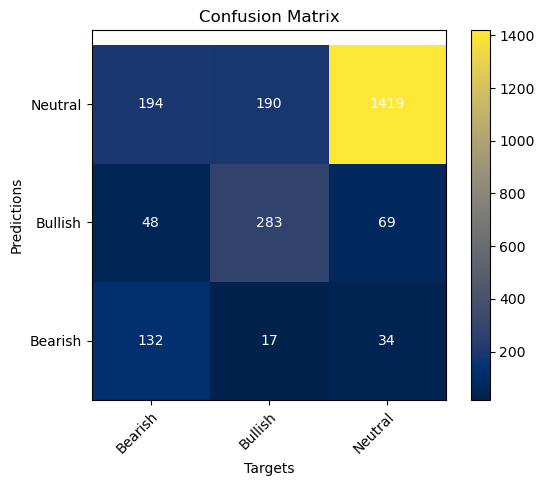

In [324]:
confusion_matrix(y_pred_rf, y_test)
plot_cm(confusion_matrix(y_pred_rf, y_test), labels.keys())

In [ ]:
 print(classification_report(y_pred_rf_w2v, y_test, target_names = labels.keys()))

              precision    recall  f1-score   support

     Bearish       0.03      0.48      0.06        23
     Bullish       0.09      0.53      0.16        87
     Neutral       0.97      0.65      0.78      2276

    accuracy                           0.65      2386
   macro avg       0.37      0.55      0.33      2386
weighted avg       0.93      0.65      0.75      2386



## Sumary table

In [327]:
predictions = {
"y_pred_bow_KNN5": y_pred_knn_bow5,
"y_pred_bow_KNN10": y_pred_knn_bow10,
"y_pred_bow_KNN20": y_pred_knn_bow20,
"y_pred_bow_LR": y_pred_lr_bow,
"y_pred_bow_MLP": y_pred_mlp_bow,
"y_pred_bow_NB": y_pred_nb_bow,
"y_pred_bow_RF": y_pred_rf_bow,

"y_pred_tfidf_KNN5": y_pred_knn_tfidf5,
"y_pred_tfidf_KNN10": y_pred_knn_tfidf10,
"y_pred_tfidf_KNN20": y_pred_knn_tfidf20,
"y_pred_tfidf_LR": y_pred_lr,
"y_pred_tfidf_MLP": y_pred_mlp,
"y_pred_tfidf_NB": y_pred_nb,
"y_pred_tfidf_RF": y_pred_rf,

"y_pred_w2v_KNN5": y_pred_knn_w2v5,
"y_pred_w2v_KNN10": y_pred_knn_w2v10,
"y_pred_w2v_KNN20": y_pred_knn_w2v20,
"y_pred_w2v_LR": y_pred_lr_w2v,
"y_pred_w2v_MLP": y_pred_mlp_w2v,
"y_pred_w2v_NB": y_pred_nb_w2v,
"y_pred_w2v_RF": y_pred_rf_w2v,

"y_pred_sentence2vector_KNN5": y_pred_knn_set2vec5,
"y_pred_sentence2vector_KNN10": y_pred_knn_set2vec10,
"y_pred_sentence2vector_KNN20": y_pred_knn_set2vec20,
"y_pred_sentence2vector_LR": y_pred_lr_set2vec,
"y_pred_sentence2vector_MLP": y_pred_mlp_set2vec,
"y_pred_sentence2vector_NB": y_pred_nb_set2vec,
"y_pred_sentence2vector_RF": y_pred_rf_set2vec,

"y_pred_sentence_transformer_KNN5": y_pred_knn_ST5,
"y_pred_sentence_transformer_KNN10": y_pred_knn_ST10,
"y_pred_sentence_transformer_KNN20": y_pred_knn_ST20,
"y_pred_sentence_transformer_LR": y_pred_lr_ST,
"y_pred_sentence_transformer_MLP": y_pred_mlp_ST,
"y_pred_sentence_transformer_NB": y_pred_nb_ST,
"y_pred_sentence_transformer_RF": y_pred_rf_st,
}

In [341]:
# Initialize results
results = []

# Calculate accuracy for each encoding and classifier
for name, preds in predictions.items():
    # Extract encoding and classifier from array name
    encoding = re.search(r"(bow|tfidf|w2v|sentence2vector|sentence_transformer)", name).group(1)
    classifier = re.search(r"(KNN5|KNN10|KNN20|LR|MLP|NB|RF)", name).group(1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, preds)

    # Store results
    results.append({"Encoding": encoding, "Classifier": classifier, "Accuracy": accuracy})

# Convert to DataFrame
df = pd.DataFrame(results)

# Pivot to desired table format
table = df.pivot(index="Encoding", columns="Classifier", values="Accuracy")

# Function to highlight top 5 accuracy scores across the entire table
def highlight_top_5(s):
    # Flatten the DataFrame to a series
    flat_s = s.unstack()
    # Get the top 5 values
    top_5 = flat_s.nlargest(5)
    # Return highlighting for the top 5 values
    return pd.DataFrame(
        [['background-color: #BED62F' if (col, idx) in top_5.index else '' for col in s.columns] for idx in s.index],
        index=s.index,
        columns=s.columns
    )

# Apply styling
styled_table = table.style.apply(highlight_top_5, axis=None)

# Display the styled table
styled_table


Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.752305,0.744342,0.751048,0.795474,0.682733,0.618189,0.777871
sentence2vector,0.685666,0.687343,0.670997,0.667225,0.658843,0.576278,0.660520
sentence_transformer,0.761106,0.752305,0.754820,0.772842,0.760687,0.672674,0.694468
tfidf,0.770746,0.766136,0.755658,0.778290,0.745180,0.684828,0.768650
w2v,0.639564,0.653395,0.611484,0.637888,0.637888,0.486169,0.642079


In [343]:
# Initialize results
results = []

# Calculate precision for each encoding and classifier
for name, preds in predictions.items():
    # Extract encoding and classifier from array name
    encoding = re.search(r"(bow|tfidf|w2v|sentence2vector|sentence_transformer)", name).group(1)
    classifier = re.search(r"(KNN5|KNN10|KNN20|LR|MLP|NB|RF)", name).group(1)

    # Calculate precision for each label
    for label_name, label_value in labels.items():
        precision = precision_score(y_test, preds, labels=[label_value], average='micro')
        results.append({"Encoding": encoding, "Classifier": classifier, "Label": label_name, "Precision": precision})

# Convert to DataFrame
df = pd.DataFrame(results)

# Separate tables for each label
tables = {}
for label in labels.keys():
    # Filter DataFrame for the current label
    label_df = df[df["Label"] == label]

    # Pivot to desired table format
    table = label_df.pivot(index="Encoding", columns="Classifier", values="Precision")

    # Highlight the top 5 precision scores in each table
    def highlight_top_5(s):
        flat_s = s.unstack()
        top_5 = flat_s.nlargest(5)
        return pd.DataFrame(
            [['background-color: #BED62F' if (col, idx) in top_5.index else '' for col in s.columns] for idx in s.index],
            index=s.index,
            columns=s.columns
        )

    # Apply styling and add title with the measure name
    measure_name = "Precision Measure"
    styled_table = table.style.apply(highlight_top_5, axis=None).set_caption(f"Precision Scores for {label} Class ({measure_name})")
    tables[label] = styled_table

# Display the tables
tables["Bearish"], tables["Bullish"], tables["Neutral"]


C:\Users\marta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\marta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\marta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\marta\anaconda3\Lib\site-packages\sklearn\metrics\_clas

(<pandas.io.formats.style.Styler at 0x1fe801e9940>,
 <pandas.io.formats.style.Styler at 0x1fe801f2420>)

In [345]:
# Display the tables
tables["Bearish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.697297,0.794872,0.610487,0.715953,0.311615,0.336222,0.792899
sentence2vector,0.521008,0.555556,0.415730,0.448819,0.392045,0.278752,0.593750
sentence_transformer,0.680000,0.726776,0.638889,0.686992,0.580460,0.492823,0.861111
tfidf,0.717172,0.791367,0.623431,0.840000,0.367816,1.000000,0.721311
w2v,0.361446,0.461538,0.248619,0.000000,0.000000,0.159091,0.615385


In [347]:
tables["Bullish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.645833,0.680115,0.638889,0.726415,0.566308,0.467091,0.724490
sentence2vector,0.540070,0.602679,0.494536,0.459016,0.416431,0.369932,0.502857
sentence_transformer,0.616052,0.621827,0.588803,0.707895,0.681818,0.457060,0.823529
tfidf,0.682500,0.713514,0.626068,0.740437,0.701835,0.821705,0.707500
w2v,0.418972,0.511905,0.388102,0.000000,0.000000,0.251289,0.465909


In [349]:
tables["Neutral"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.780407,0.752862,0.802015,0.824633,0.815593,0.792975,0.787945
sentence2vector,0.716667,0.700957,0.730727,0.713920,0.730210,0.790788,0.674162
sentence_transformer,0.811176,0.783306,0.826114,0.798864,0.819753,0.846995,0.683830
tfidf,0.796421,0.774640,0.810602,0.780749,0.838951,0.675712,0.787022
w2v,0.678049,0.666515,0.689525,0.637888,0.637888,0.653417,0.649015


In [351]:
# Initialize results
results = []

# Calculate recall for each encoding and classifier
for name, preds in predictions.items():
    # Extract encoding and classifier from array name
    encoding = re.search(r"(bow|tfidf|w2v|sentence2vector|sentence_transformer)", name).group(1)
    classifier = re.search(r"(KNN5|KNN10|KNN20|LR|MLP|NB|RF)", name).group(1)

    # Calculate recall for each label
    for label_name, label_value in labels.items():
        recall = recall_score(y_test, preds, labels=[label_value], average='micro')
        results.append({"Encoding": encoding, "Classifier": classifier, "Label": label_name, "Recall": recall})

# Convert to DataFrame
df = pd.DataFrame(results)

# Separate tables for each label
tables = {}
for label in labels.keys():
    # Filter DataFrame for the current label
    label_df = df[df["Label"] == label]

    # Pivot to desired table format
    table = label_df.pivot(index="Encoding", columns="Classifier", values="Recall")

    # Highlight the top 5 recall scores in each table
    def highlight_top_5(s):
        flat_s = s.unstack()
        top_5 = flat_s.nlargest(5)
        return pd.DataFrame(
            [['background-color: #BED62F' if (col, idx) in top_5.index else '' for col in s.columns] for idx in s.index],
            index=s.index,
            columns=s.columns
        )

    # Apply styling and add title with the measure name
    measure_name = "Recall Measure"
    styled_table = table.style.apply(highlight_top_5, axis=None).set_caption(f"Recall Scores for {label} Class ({measure_name})")
    tables[label] = styled_table

# Display the tables
tables["Bearish"], tables["Bullish"], tables["Neutral"]


(<pandas.io.formats.style.Styler at 0x1ffe43989e0>,
 <pandas.io.formats.style.Styler at 0x1ffed887f20>)

In [353]:
tables["Bearish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.344920,0.248663,0.435829,0.491979,0.294118,0.518717,0.358289
sentence2vector,0.165775,0.106952,0.197861,0.152406,0.184492,0.382353,0.050802
sentence_transformer,0.409091,0.355615,0.430481,0.451872,0.540107,0.550802,0.082888
tfidf,0.379679,0.294118,0.398396,0.336898,0.342246,0.024064,0.352941
w2v,0.080214,0.032086,0.120321,0.000000,0.000000,0.074866,0.021390


In [355]:
tables["Bullish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.506122,0.481633,0.563265,0.628571,0.644898,0.448980,0.579592
sentence2vector,0.316327,0.275510,0.369388,0.285714,0.300000,0.446939,0.179592
sentence_transformer,0.579592,0.500000,0.622449,0.548980,0.581633,0.640816,0.228571
tfidf,0.557143,0.538776,0.597959,0.553061,0.624490,0.216327,0.577551
w2v,0.216327,0.175510,0.279592,0.000000,0.000000,0.397959,0.083673


In [357]:
tables["Neutral"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.931669,0.950723,0.888962,0.923784,0.790407,0.697109,0.944809
sentence2vector,0.932326,0.962549,0.884363,0.916557,0.890933,0.665572,0.965177
sentence_transformer,0.906045,0.931012,0.877135,0.923784,0.872536,0.712878,0.994744
tfidf,0.935611,0.955322,0.894218,0.959264,0.883049,0.998029,0.932326
w2v,0.913272,0.959921,0.839028,1.000000,1.000000,0.615637,0.974376


In [359]:
# Initialize results
results = []

# Calculate F1 score for each encoding and classifier
for name, preds in predictions.items():
    # Extract encoding and classifier from array name
    encoding = re.search(r"(bow|tfidf|w2v|sentence2vector|sentence_transformer)", name).group(1)
    classifier = re.search(r"(KNN5|KNN10|KNN20|LR|MLP|NB|RF)", name).group(1)

    # Calculate F1 score for each label
    for label_name, label_value in labels.items():
        f1 = f1_score(y_test, preds, labels=[label_value], average='micro')
        results.append({"Encoding": encoding, "Classifier": classifier, "Label": label_name, "F1": f1})

# Convert to DataFrame
df = pd.DataFrame(results)

# Separate tables for each label
tables = {}
for label in labels.keys():
    # Filter DataFrame for the current label
    label_df = df[df["Label"] == label]

    # Pivot to desired table format
    table = label_df.pivot(index="Encoding", columns="Classifier", values="F1")


    # Highlight the top 5 F1 scores in each table
    def highlight_top_5(s):
        flat_s = s.unstack()
        top_5 = flat_s.nlargest(5)
        return pd.DataFrame(
            [['background-color: #BED62F' if (col, idx) in top_5.index else '' for col in s.columns] for idx in s.index],
            index=s.index,
            columns=s.columns
        )

    # Apply styling and add title with the measure name
    measure_name = "F1-Score Measure"
    styled_table = table.style.apply(highlight_top_5, axis=None).set_caption(f"F1-Score for {label} Class ({measure_name})")
    tables[label] = styled_table

# Display the tables
tables["Bearish"], tables["Bullish"], tables["Neutral"]


(<pandas.io.formats.style.Styler at 0x1ffed8aee70>,
 <pandas.io.formats.style.Styler at 0x1fe80168e90>)

In [361]:
tables["Bearish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.461538,0.378819,0.508580,0.583201,0.302613,0.407992,0.493554
sentence2vector,0.251521,0.179372,0.268116,0.227545,0.250909,0.322435,0.093596
sentence_transformer,0.510851,0.477558,0.514377,0.545161,0.559557,0.520202,0.151220
tfidf,0.496503,0.428850,0.486134,0.480916,0.354571,0.046997,0.473968
w2v,0.131291,0.060000,0.162162,0.000000,0.000000,0.101818,0.041344


In [363]:
tables["Bullish"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.567506,0.563919,0.598698,0.673961,0.603053,0.457856,0.643991
sentence2vector,0.398970,0.378151,0.422897,0.352201,0.348754,0.404806,0.264662
sentence_transformer,0.597266,0.554299,0.605159,0.618391,0.627753,0.533560,0.357827
tfidf,0.613483,0.613953,0.611691,0.633178,0.660907,0.342488,0.635955
w2v,0.285330,0.261398,0.325030,0.000000,0.000000,0.308057,0.141869


In [365]:
tables["Neutral"]

Classifier,KNN10,KNN20,KNN5,LR,MLP,NB,RF
Encoding,,,,,,,
bow,0.849356,0.840302,0.843253,0.871398,0.802803,0.741958,0.859277
sentence2vector,0.810394,0.811185,0.800238,0.802647,0.802604,0.722797,0.793840
sentence_transformer,0.855990,0.850796,0.850860,0.856795,0.845321,0.774171,0.810493
tfidf,0.860423,0.855546,0.850359,0.860849,0.860435,0.805836,0.853534
w2v,0.778275,0.786753,0.756965,0.778915,0.778915,0.633965,0.779091


In [ ]:
# Plot all ROC curves
plt.figure(figsize=(15, 10))
for model_name, y_pred in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multiple Models')
plt.legend(loc='lower right')
plt.show()


# Final Result

The structure of these dataset is the same as the train set, except that it does not
contain the “label” column. You are expected to provide the predicted status (0, 1 or 2) for each tweet
in this set and we will compare your predictions with the actual (true) labels.

In [630]:
#apply the model to the test data
df_pred = pd.read_csv("test.csv")

In [634]:
print(df_pred.isna().sum())

id      0
text    0
dtype: int64


In [585]:
tokenizer = AutoTokenizer.from_pretrained("./sentiment_model_g18_3")
model = AutoModelForSequenceClassification.from_pretrained("./sentiment_model_g18_3")

In [650]:
def predict_sentiment(x):
    with torch.no_grad():
        input_sequence = tokenizer(x, return_tensors="pt", **tokenizer_kwargs)
        logits = model(**input_sequence).logits
        scores = {
            k: v
            for k, v in zip(
                model.config.id2label.values(),
                scipy.special.softmax(logits.numpy().squeeze()),
            )
        }
        sentimentFinbert = max(scores, key=scores.get)
        return sentimentFinbert

# Apply the prediction function to create a new column
df_pred['label'] = df_pred['text'].apply(predict_sentiment)

In [683]:
df_pred

,id,text,label
0,0,ETF assets to surge tenfold in 10 years to $50...,Positive
1,1,Here’s What Hedge Funds Think Evolution Petrol...,Neutral
2,2,$PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...,Neutral
3,3,China is in the process of waiving retaliatory...,Neutral
4,4,"Highlight: “When growth is scarce, investors s...",Neutral
...,...,...,...
2383,2383,$IVC - Invacare Corporation (IVC) CEO Matthew ...,Neutral
2384,2384,"Domtar EPS misses by $0.05, revenue in-line",Negative
2385,2385,India Plans Incentives to Bring In Foreign Man...,Neutral
2386,2386,$NVCR shows institutional accumulation with bl...,Neutral


In [685]:
# Define the mapping as Negative/Bearish (0), Positive/Bullish (1), or Neutral (2)
mapping = {'Neutral': 2, 'Negative': 0, 'Positive': 1}
df_pred_map=df_pred.copy()
# Map the 'prediction' column using the mapping
df_pred_map['label'] = df_pred_map['label'].map(mapping)
df_pred_map.head(10)

,id,text,label
0,0,ETF assets to surge tenfold in 10 years to $50...,1
1,1,Here’s What Hedge Funds Think Evolution Petrol...,2
2,2,$PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...,2
3,3,China is in the process of waiving retaliatory...,2
4,4,"Highlight: “When growth is scarce, investors s...",2
5,5,Marvell Technology (MRVL) Gains As Market Dips...,1
6,6,UPDATE 1-Italian airline Alitalia's rescue in ...,2
7,7,why macro funds are shutting down left and rig...,0
8,8,Uber's arrival caused binge drinking to increa...,2
9,9,New Dungeons & Dragons game announced,2


In [687]:
df_pred_exp = df_pred_map.drop('text', axis=1)
df_pred_exp.head(15)

,id,label
0,0,1
1,1,2
2,2,2
3,3,2
4,4,2
5,5,1
6,6,2
7,7,0
8,8,2
9,9,2


In [689]:
#export
df_pred_exp.to_csv('Predictions_18.csv', index=False, sep=';')